# Build Main And Aux Datasets

Notebook nay tao 2 bo manifest moi tu 2 nguon du lieu goc:
- NIH Chest X-rays raw images
- Chest X-Ray Pneumonia raw images

Dau ra:
1. Main task 3 lop:
- `normal`
- `pneumonia_only`
- `effusion_only`

Ty le tao moi:
- train: `2 : 1 : 1`
- val: `70 : 15 : 15`
- test: `70 : 15 : 15`

2. Aux task cho bai `jiki`:
- `normal`
- `effusion_only`
- chi dung NIH-only
- train can bang `1 : 1`
- val/test giu split NIH tu nhien


In [1]:
import json
import os
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

SEED = 42
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
VALID_IMAGE_EXTS = {".png", ".jpg", ".jpeg"}

MAIN_CLASS_NAMES = ["normal", "pneumonia_only", "effusion_only"]
AUX_CLASS_NAMES = ["normal", "effusion_only"]

OUTPUT_DIR = Path("/kaggle/working/pbl4_main_aux_datasets")
MANIFEST_DIR = OUTPUT_DIR / "manifests"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
for directory in [OUTPUT_DIR, MANIFEST_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NIH_IMAGE_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/organizations/nih-chest-xrays/data",
    "/kaggle/input/nih-chest-xrays/data",
    "/kaggle/input/chest-xray14/images",
]

EXTERNAL_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray",
    "/kaggle/input/chest-xray-pneumonia/chest_xray",
]

print("Dataset build configuration")
print(f"- output dir: {OUTPUT_DIR}")
print(f"- split ratios: train={TRAIN_RATIO}, val={VAL_RATIO}, test={TEST_RATIO}")


Dataset build configuration
- output dir: /kaggle/working/pbl4_main_aux_datasets
- split ratios: train=0.8, val=0.1, test=0.1


In [2]:
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)


def find_existing_dir(candidates):
    for candidate in candidates:
        candidate_path = Path(candidate)
        if candidate_path.exists():
            return candidate_path
    raise FileNotFoundError(f"Could not find any valid directory from: {candidates}")


def normalize_column_name(column_name):
    normalized = column_name.strip().lower()
    normalized = re.sub(r"[^a-z0-9]+", "_", normalized)
    normalized = re.sub(r"_+", "_", normalized).strip("_")
    return normalized


def find_nih_metadata_csv(image_root):
    search_roots = []
    for candidate in [image_root.parent, image_root.parent.parent, image_root.parent.parent.parent]:
        if candidate.exists() and candidate not in search_roots:
            search_roots.append(candidate)

    exact_names = ["Data_Entry_2017_v2020.csv", "Data_Entry_2017.csv"]
    for root in search_roots:
        for name in exact_names:
            path = root / name
            if path.exists():
                return path

    matches = []
    for root in search_roots:
        matches.extend(sorted(root.rglob("Data_Entry*.csv")))
    if matches:
        return matches[0]
    raise FileNotFoundError("Could not find NIH metadata CSV matching Data_Entry*.csv")


def build_image_index(search_root):
    image_map = {}
    duplicate_names = set()
    image_paths = sorted(path for path in search_root.rglob("*") if path.suffix.lower() in VALID_IMAGE_EXTS)
    for image_path in image_paths:
        image_name = image_path.name
        if image_name in image_map and image_map[image_name] != str(image_path):
            duplicate_names.add(image_name)
            continue
        image_map.setdefault(image_name, str(image_path))
    return image_map, duplicate_names


def load_nih_metadata(metadata_csv_path):
    df = pd.read_csv(metadata_csv_path)
    rename_map = {column: normalize_column_name(column) for column in df.columns}
    df = df.rename(columns=rename_map)
    required = ["image_index", "finding_labels"]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(f"Missing NIH metadata columns: {missing}")
    if "patient_id" not in df.columns:
        df["patient_id"] = df["image_index"].astype(str)
    if "view_position" not in df.columns:
        df["view_position"] = "UNK"
    return df


def parse_label_tokens(label_text):
    if pd.isna(label_text):
        return []
    return [token.strip() for token in str(label_text).split("|") if token.strip()]


def classify_nih_group(label_text):
    token_set = set(parse_label_tokens(label_text))
    if token_set == {"No Finding"}:
        return "normal", True
    if token_set == {"Effusion"}:
        return "effusion_only", True
    if token_set == {"Pneumonia"}:
        return "nih_pneumonia_only_excluded", False
    if "Effusion" in token_set:
        return "nih_effusion_mixed_excluded", False
    if "Pneumonia" in token_set:
        return "nih_pneumonia_mixed_excluded", False
    return "nih_other_excluded", False


PERSON_PATTERN = re.compile(r"^(person\d+)", re.IGNORECASE)


def infer_external_patient_group_id(image_path):
    stem = image_path.stem
    match = PERSON_PATTERN.match(stem)
    if match:
        return f"external_{match.group(1).lower()}"
    hyphen_parts = stem.split("-")
    if len(hyphen_parts) > 1 and hyphen_parts[-1].isdigit():
        return f"external_{'-'.join(hyphen_parts[:-1]).lower()}"
    underscore_parts = stem.split("_")
    if len(underscore_parts) > 2 and underscore_parts[-1].isdigit():
        return f"external_{'_'.join(underscore_parts[:-1]).lower()}"
    return f"external_{stem.lower()}"


def safe_train_val_test_split(index_values, stratify_values, train_ratio, val_ratio, test_ratio, random_state=42):
    index_values = list(index_values)
    stratify_series = pd.Series(stratify_values, index=index_values)

    first_stratify = None
    counts = stratify_series.value_counts()
    if len(counts) > 1 and counts.min() >= 2:
        first_stratify = stratify_series.loc[index_values]

    train_ids, temp_ids = train_test_split(
        index_values,
        train_size=train_ratio,
        random_state=random_state,
        stratify=first_stratify,
    )

    temp_series = stratify_series.loc[temp_ids]
    second_stratify = None
    counts = temp_series.value_counts()
    if len(counts) > 1 and counts.min() >= 2:
        second_stratify = temp_series

    relative_val = val_ratio / (val_ratio + test_ratio)
    val_ids, test_ids = train_test_split(
        temp_ids,
        train_size=relative_val,
        random_state=random_state,
        stratify=second_stratify,
    )
    return set(train_ids), set(val_ids), set(test_ids)


def assign_split_patientwise(frame):
    grouped = frame.groupby("patient_group_id", as_index=False).agg({"class_name": "first"})
    train_ids, val_ids, test_ids = safe_train_val_test_split(
        grouped["patient_group_id"],
        grouped["class_name"],
        TRAIN_RATIO,
        VAL_RATIO,
        TEST_RATIO,
        random_state=SEED,
    )
    split_map = {}
    split_map.update({key: "train" for key in train_ids})
    split_map.update({key: "val" for key in val_ids})
    split_map.update({key: "test" for key in test_ids})
    split_df = frame.copy()
    split_df["split"] = split_df["patient_group_id"].map(split_map)
    return split_df


def sample_without_replacement(frame, n, random_state):
    if n <= 0:
        return frame.iloc[0:0].copy()
    if len(frame) < n:
        raise ValueError(f"Cannot sample {n} rows from only {len(frame)} available rows.")
    return frame.sample(n=n, replace=False, random_state=random_state).copy()


def allocate_normal_counts(normal_nih_df, normal_external_df, total_target, seed=42):
    normal_external_target = min(int(round(total_target * 0.50)), len(normal_external_df))
    normal_nih_target = min(total_target - normal_external_target, len(normal_nih_df))
    remaining = total_target - normal_external_target - normal_nih_target

    if remaining > 0:
        external_remaining = len(normal_external_df) - normal_external_target
        extra_external = min(remaining, max(external_remaining, 0))
        normal_external_target += extra_external
        remaining -= extra_external

    if remaining > 0:
        nih_remaining = len(normal_nih_df) - normal_nih_target
        extra_nih = min(remaining, max(nih_remaining, 0))
        normal_nih_target += extra_nih
        remaining -= extra_nih

    if remaining > 0:
        raise ValueError("Not enough normal samples to satisfy target.")

    return normal_nih_target, normal_external_target


In [3]:
seed_everything(SEED)
NIH_IMAGE_ROOT = find_existing_dir(NIH_IMAGE_ROOT_CANDIDATES)
EXTERNAL_ROOT = find_existing_dir(EXTERNAL_ROOT_CANDIDATES)
NIH_METADATA_CSV = find_nih_metadata_csv(NIH_IMAGE_ROOT)

print(f"NIH_IMAGE_ROOT: {NIH_IMAGE_ROOT}")
print(f"EXTERNAL_ROOT: {EXTERNAL_ROOT}")
print(f"NIH_METADATA_CSV: {NIH_METADATA_CSV}")

nih_metadata_df = load_nih_metadata(NIH_METADATA_CSV)
nih_image_map, duplicate_names = build_image_index(NIH_IMAGE_ROOT)
print(f"Indexed NIH images: {len(nih_image_map):,}")
print(f"Duplicate NIH filenames skipped: {len(duplicate_names):,}")
display(nih_metadata_df.head(5))


NIH_IMAGE_ROOT: /kaggle/input/datasets/organizations/nih-chest-xrays/data
EXTERNAL_ROOT: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
NIH_METADATA_CSV: /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
Indexed NIH images: 112,120
Duplicate NIH filenames skipped: 0


,image_index,finding_labels,follow_up,patient_id,patient_age,patient_gender,view_position,originalimage_width,height,originalimagepixelspacing_x,y,unnamed_11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
classifications = nih_metadata_df["finding_labels"].apply(classify_nih_group)
nih_class_names = classifications.apply(lambda x: x[0])
nih_selected_clean = classifications.apply(lambda x: x[1])

nih_manifest = pd.DataFrame({
    "sample_id": nih_metadata_df["image_index"].astype(str).map(lambda x: f"nih_{x}"),
    "source": "nih",
    "original_split": "raw",
    "resolved_path": nih_metadata_df["image_index"].map(nih_image_map),
    "patient_id": nih_metadata_df["patient_id"].astype(str),
    "patient_group_id": nih_metadata_df["patient_id"].astype(str).map(lambda x: f"nih_patient_{x}"),
    "view_position": nih_metadata_df["view_position"].astype(str),
    "finding_labels_raw": nih_metadata_df["finding_labels"].astype(str),
    "class_name": nih_class_names,
    "selected_clean": nih_selected_clean.astype(bool),
})
nih_manifest["resolved_path"] = nih_manifest["resolved_path"].astype(str)
missing_nih = ~nih_manifest["resolved_path"].map(lambda x: Path(str(x)).exists())
if missing_nih.any():
    examples = nih_manifest.loc[missing_nih, "sample_id"].head(5).tolist()
    raise FileNotFoundError(f"Missing NIH image paths. Examples: {examples}")

external_rows = []
class_map = {"NORMAL": "normal", "PNEUMONIA": "pneumonia_only"}
for original_split in ["train", "val", "test"]:
    split_dir = EXTERNAL_ROOT / original_split
    if not split_dir.exists():
        continue
    for folder_name, class_name in class_map.items():
        class_dir = split_dir / folder_name
        if not class_dir.exists():
            continue
        image_paths = sorted(path for path in class_dir.rglob("*") if path.suffix.lower() in VALID_IMAGE_EXTS)
        for image_path in image_paths:
            relative_key = str(image_path.relative_to(EXTERNAL_ROOT)).replace(os.sep, "_")
            external_rows.append({
                "sample_id": f"external_{relative_key}",
                "source": "chest_xray_pneumonia",
                "original_split": original_split,
                "resolved_path": str(image_path),
                "patient_id": image_path.stem,
                "patient_group_id": infer_external_patient_group_id(image_path),
                "view_position": "UNK",
                "finding_labels_raw": folder_name,
                "class_name": class_name,
                "selected_clean": True,
            })

external_manifest = pd.DataFrame(external_rows)
if external_manifest.empty:
    raise FileNotFoundError(f"No external images found under {EXTERNAL_ROOT}")

nih_manifest.to_csv(MANIFEST_DIR / "nih_raw_manifest.csv", index=False)
external_manifest.to_csv(MANIFEST_DIR / "external_raw_manifest.csv", index=False)

display(nih_manifest["class_name"].value_counts().rename_axis("class_name").reset_index(name="samples"))
display(external_manifest["class_name"].value_counts().rename_axis("class_name").reset_index(name="samples"))


,class_name,samples
0,normal,60361
1,nih_other_excluded,37280
2,nih_effusion_mixed_excluded,9362
3,effusion_only,3955
4,nih_pneumonia_mixed_excluded,840
5,nih_pneumonia_only_excluded,322


,class_name,samples
0,pneumonia_only,4273
1,normal,1583


In [5]:
nih_clean_df = nih_manifest.loc[nih_manifest["selected_clean"]].copy().reset_index(drop=True)
nih_excluded_df = nih_manifest.loc[~nih_manifest["selected_clean"]].copy().reset_index(drop=True)

nih_clean_df = assign_split_patientwise(nih_clean_df)
external_manifest = assign_split_patientwise(external_manifest)

main_clean_all_df = pd.concat([nih_clean_df, external_manifest], ignore_index=True)
main_clean_all_df["class_index"] = main_clean_all_df["class_name"].map({name: idx for idx, name in enumerate(MAIN_CLASS_NAMES)}).fillna(-1).astype(int)

main_clean_all_df.to_csv(MANIFEST_DIR / "main_clean_all.csv", index=False)
nih_clean_df.to_csv(MANIFEST_DIR / "nih_clean_selected.csv", index=False)
nih_excluded_df.to_csv(MANIFEST_DIR / "nih_excluded.csv", index=False)
external_manifest.to_csv(MANIFEST_DIR / "external_clean_selected.csv", index=False)

clean_summary_df = (
    main_clean_all_df.groupby(["split", "source", "class_name"], dropna=False)
    .size()
    .reset_index(name="samples")
    .sort_values(["split", "source", "class_name"])
)
clean_summary_df.to_csv(ARTIFACT_DIR / "clean_split_source_class_summary.csv", index=False)

display(clean_summary_df)
display(nih_excluded_df["class_name"].value_counts().rename_axis("class_name").reset_index(name="samples"))


,split,source,class_name,samples
0,test,chest_xray_pneumonia,normal,176
1,test,chest_xray_pneumonia,pneumonia_only,364
2,test,nih,effusion_only,454
3,test,nih,normal,6054
4,train,chest_xray_pneumonia,normal,1241
5,train,chest_xray_pneumonia,pneumonia_only,3493
6,train,nih,effusion_only,3095
7,train,nih,normal,48142
8,val,chest_xray_pneumonia,normal,166
9,val,chest_xray_pneumonia,pneumonia_only,416


,class_name,samples
0,nih_other_excluded,37280
1,nih_effusion_mixed_excluded,9362
2,nih_pneumonia_mixed_excluded,840
3,nih_pneumonia_only_excluded,322


In [6]:
def build_main_train_manifest(train_df):
    pneumonia_df = train_df.loc[train_df["class_name"] == "pneumonia_only"].copy()
    effusion_df = train_df.loc[train_df["class_name"] == "effusion_only"].copy()
    normal_nih_df = train_df.loc[(train_df["class_name"] == "normal") & (train_df["source"] == "nih")].copy()
    normal_external_df = train_df.loc[(train_df["class_name"] == "normal") & (train_df["source"] == "chest_xray_pneumonia")].copy()

    target = min(len(pneumonia_df), len(effusion_df))
    normal_target = min(2 * target, len(normal_nih_df) + len(normal_external_df))
    normal_nih_target, normal_external_target = allocate_normal_counts(normal_nih_df, normal_external_df, normal_target, seed=SEED)

    parts = [
        sample_without_replacement(pneumonia_df, target, SEED),
        sample_without_replacement(effusion_df, target, SEED + 1),
    ]
    if normal_nih_target > 0:
        parts.append(sample_without_replacement(normal_nih_df, normal_nih_target, SEED + 2))
    if normal_external_target > 0:
        parts.append(sample_without_replacement(normal_external_df, normal_external_target, SEED + 3))

    balanced_df = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    plan_df = pd.DataFrame([
        {"class_name": "normal", "target_count": int(normal_target), "notes": f"nih={normal_nih_target}, external={normal_external_target}"},
        {"class_name": "pneumonia_only", "target_count": int(target), "notes": "external only"},
        {"class_name": "effusion_only", "target_count": int(target), "notes": "nih only"},
    ])
    return balanced_df, plan_df


def build_main_eval_manifest(split_df):
    pneumonia_df = split_df.loc[split_df["class_name"] == "pneumonia_only"].copy()
    effusion_df = split_df.loc[split_df["class_name"] == "effusion_only"].copy()
    normal_nih_df = split_df.loc[(split_df["class_name"] == "normal") & (split_df["source"] == "nih")].copy()
    normal_external_df = split_df.loc[(split_df["class_name"] == "normal") & (split_df["source"] == "chest_xray_pneumonia")].copy()

    disease_target = min(len(pneumonia_df), len(effusion_df))
    normal_target = min(int(round(disease_target * (70.0 / 15.0))), len(normal_nih_df) + len(normal_external_df))
    normal_nih_target, normal_external_target = allocate_normal_counts(normal_nih_df, normal_external_df, normal_target, seed=SEED)

    parts = [
        sample_without_replacement(pneumonia_df, disease_target, SEED),
        sample_without_replacement(effusion_df, disease_target, SEED + 1),
    ]
    if normal_nih_target > 0:
        parts.append(sample_without_replacement(normal_nih_df, normal_nih_target, SEED + 2))
    if normal_external_target > 0:
        parts.append(sample_without_replacement(normal_external_df, normal_external_target, SEED + 3))
    ratio_df = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return ratio_df


In [7]:
main_train_clean_df = main_clean_all_df.loc[main_clean_all_df["split"] == "train"].copy().reset_index(drop=True)
main_val_clean_original_df = main_clean_all_df.loc[main_clean_all_df["split"] == "val"].copy().reset_index(drop=True)
main_test_clean_original_df = main_clean_all_df.loc[main_clean_all_df["split"] == "test"].copy().reset_index(drop=True)

main_train_2_1_1_df, main_train_plan_df = build_main_train_manifest(main_train_clean_df)
main_val_70_15_15_df = build_main_eval_manifest(main_val_clean_original_df)
main_test_70_15_15_df = build_main_eval_manifest(main_test_clean_original_df)

main_train_2_1_1_df.to_csv(MANIFEST_DIR / "main_train_2_1_1.csv", index=False)
main_val_70_15_15_df.to_csv(MANIFEST_DIR / "main_val_70_15_15.csv", index=False)
main_test_70_15_15_df.to_csv(MANIFEST_DIR / "main_test_70_15_15.csv", index=False)
main_train_plan_df.to_csv(ARTIFACT_DIR / "main_train_plan.csv", index=False)

main_counts_df = pd.DataFrame({
    "class_name": MAIN_CLASS_NAMES,
    "train_2_1_1": main_train_2_1_1_df["class_name"].value_counts().reindex(MAIN_CLASS_NAMES, fill_value=0).values,
    "val_70_15_15": main_val_70_15_15_df["class_name"].value_counts().reindex(MAIN_CLASS_NAMES, fill_value=0).values,
    "test_70_15_15": main_test_70_15_15_df["class_name"].value_counts().reindex(MAIN_CLASS_NAMES, fill_value=0).values,
})
main_counts_df.to_csv(ARTIFACT_DIR / "main_counts.csv", index=False)

display(main_train_plan_df)
display(main_counts_df)


,class_name,target_count,notes
0,normal,6190,"nih=4949, external=1241"
1,pneumonia_only,3095,external only
2,effusion_only,3095,nih only


,class_name,train_2_1_1,val_70_15_15,test_70_15_15
0,normal,6190,1895,1699
1,pneumonia_only,3095,406,364
2,effusion_only,3095,406,364


In [8]:
nih_aux_all_df = nih_clean_df.loc[nih_clean_df["class_name"].isin(AUX_CLASS_NAMES)].copy().reset_index(drop=True)
aux_train_original_df = nih_aux_all_df.loc[nih_aux_all_df["split"] == "train"].copy().reset_index(drop=True)
aux_val_df = nih_aux_all_df.loc[nih_aux_all_df["split"] == "val"].copy().reset_index(drop=True)
aux_test_df = nih_aux_all_df.loc[nih_aux_all_df["split"] == "test"].copy().reset_index(drop=True)

aux_normal_train_df = aux_train_original_df.loc[aux_train_original_df["class_name"] == "normal"].copy()
aux_effusion_train_df = aux_train_original_df.loc[aux_train_original_df["class_name"] == "effusion_only"].copy()
aux_target = min(len(aux_normal_train_df), len(aux_effusion_train_df))
aux_train_balanced_df = pd.concat([
    sample_without_replacement(aux_normal_train_df, aux_target, SEED),
    sample_without_replacement(aux_effusion_train_df, aux_target, SEED + 1),
], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

aux_train_balanced_df.to_csv(MANIFEST_DIR / "effusion_train_balanced.csv", index=False)
aux_val_df.to_csv(MANIFEST_DIR / "effusion_val.csv", index=False)
aux_test_df.to_csv(MANIFEST_DIR / "effusion_test.csv", index=False)

aux_counts_df = pd.DataFrame({
    "class_name": AUX_CLASS_NAMES,
    "train_balanced": aux_train_balanced_df["class_name"].value_counts().reindex(AUX_CLASS_NAMES, fill_value=0).values,
    "val": aux_val_df["class_name"].value_counts().reindex(AUX_CLASS_NAMES, fill_value=0).values,
    "test": aux_test_df["class_name"].value_counts().reindex(AUX_CLASS_NAMES, fill_value=0).values,
})
aux_counts_df.to_csv(ARTIFACT_DIR / "aux_counts.csv", index=False)

display(aux_counts_df)


,class_name,train_balanced,val,test
0,normal,3095,6165,6054
1,effusion_only,3095,406,454


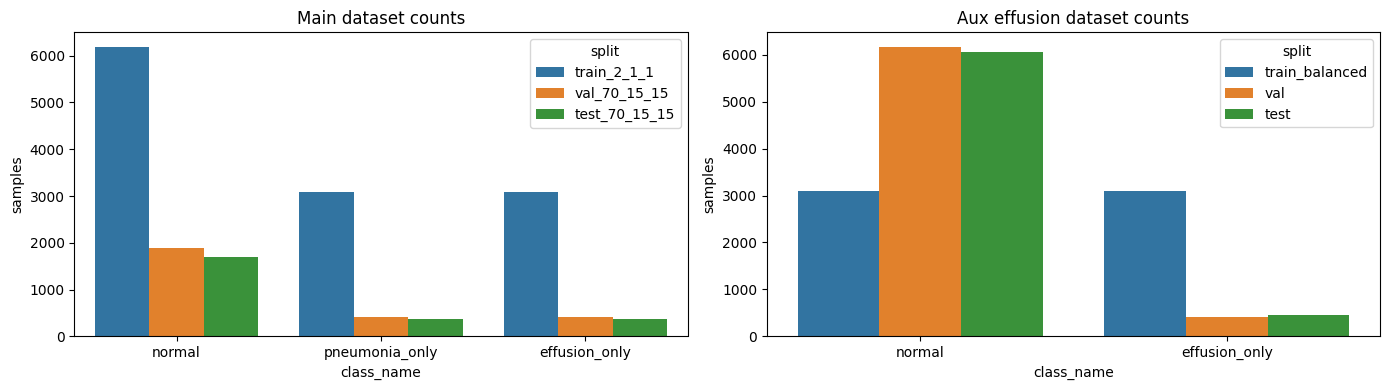

Saved files
- main train: /kaggle/working/pbl4_main_aux_datasets/manifests/main_train_2_1_1.csv
- main val: /kaggle/working/pbl4_main_aux_datasets/manifests/main_val_70_15_15.csv
- main test: /kaggle/working/pbl4_main_aux_datasets/manifests/main_test_70_15_15.csv
- aux train: /kaggle/working/pbl4_main_aux_datasets/manifests/effusion_train_balanced.csv
- aux val: /kaggle/working/pbl4_main_aux_datasets/manifests/effusion_val.csv
- aux test: /kaggle/working/pbl4_main_aux_datasets/manifests/effusion_test.csv
- dataset card: /kaggle/working/pbl4_main_aux_datasets/dataset_card.json


In [9]:
dataset_card = {
    "seed": SEED,
    "nih_image_root": str(NIH_IMAGE_ROOT),
    "nih_metadata_csv": str(NIH_METADATA_CSV),
    "external_root": str(EXTERNAL_ROOT),
    "main_train_manifest": str(MANIFEST_DIR / "main_train_2_1_1.csv"),
    "main_val_manifest": str(MANIFEST_DIR / "main_val_70_15_15.csv"),
    "main_test_manifest": str(MANIFEST_DIR / "main_test_70_15_15.csv"),
    "aux_train_manifest": str(MANIFEST_DIR / "effusion_train_balanced.csv"),
    "aux_val_manifest": str(MANIFEST_DIR / "effusion_val.csv"),
    "aux_test_manifest": str(MANIFEST_DIR / "effusion_test.csv"),
    "main_counts": main_counts_df.set_index("class_name").to_dict(),
    "aux_counts": aux_counts_df.set_index("class_name").to_dict(),
}
with open(OUTPUT_DIR / "dataset_card.json", "w", encoding="utf-8") as file_obj:
    json.dump(dataset_card, file_obj, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=main_counts_df.melt(id_vars="class_name", var_name="split", value_name="samples"), x="class_name", y="samples", hue="split", ax=axes[0])
axes[0].set_title("Main dataset counts")
sns.barplot(data=aux_counts_df.melt(id_vars="class_name", var_name="split", value_name="samples"), x="class_name", y="samples", hue="split", ax=axes[1])
axes[1].set_title("Aux effusion dataset counts")
plt.tight_layout()
plt.show()

print("Saved files")
print(f"- main train: {MANIFEST_DIR / 'main_train_2_1_1.csv'}")
print(f"- main val: {MANIFEST_DIR / 'main_val_70_15_15.csv'}")
print(f"- main test: {MANIFEST_DIR / 'main_test_70_15_15.csv'}")
print(f"- aux train: {MANIFEST_DIR / 'effusion_train_balanced.csv'}")
print(f"- aux val: {MANIFEST_DIR / 'effusion_val.csv'}")
print(f"- aux test: {MANIFEST_DIR / 'effusion_test.csv'}")
print(f"- dataset card: {OUTPUT_DIR / 'dataset_card.json'}")
